In [ ]:
!pip install opencv-python pixellib

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installi

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [1]:
import cv2

In [2]:

import numpy as np

In [3]:

import torch
import torchvision.transforms as T

In [4]:

from torchvision.models.segmentation import deeplabv3_resnet101


In [5]:
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


원본 고양이 이미지 크기: (687, 529, 3)
배경(사막) 이미지 크기: (1280, 1920, 3)


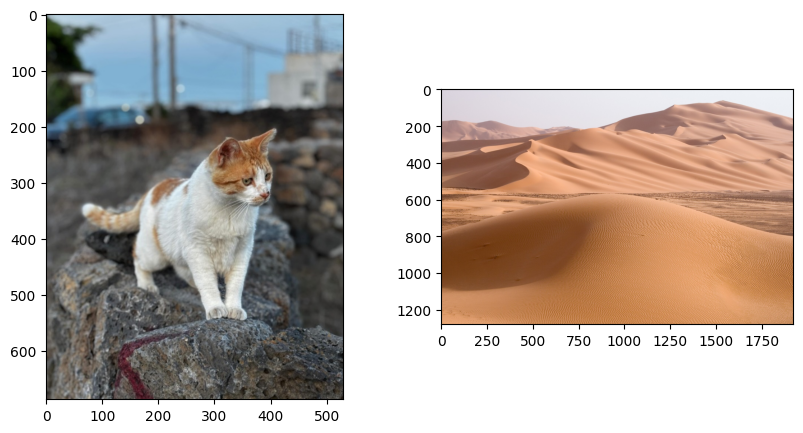

In [6]:
cat_img_path = "cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [7]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\H11\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


추론 마스크 크기 (Before Resize): (520, 520)


In [8]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (687, 529)


# Step 1. 인물모드 직접 해 보기

여러분의 셀카를 이용해서 오늘 배운 내용을 수행해 봅시다. 아래와 같은 이미지를 얻어야 합니다. 최소 3장 이상의 인물모드 사진을 만들어 봅시다.
인물이 주인공이 아닌, 귀여운 고양이에 대한 아웃포커싱 사진도 만들어 볼 수 있을 것입니다. 시맨틱 세그멘테이션 스텝에서 힌트를 찾아봅시다.
배경을 blur하는 인물모드 사진이 아니라 배경사진을 다른 이미지로 교체하는 크로마키 배경 합성을 시도해 볼 수도 있을 것입니다. 여러분만의 환상적인 사진을 만들어 보면 어떨까요?

In [10]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


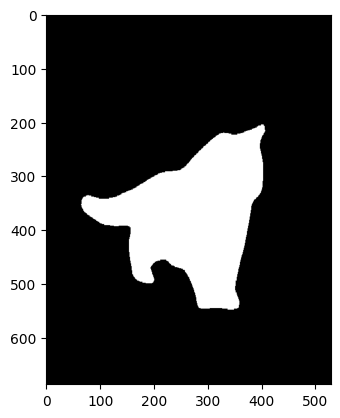

In [11]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

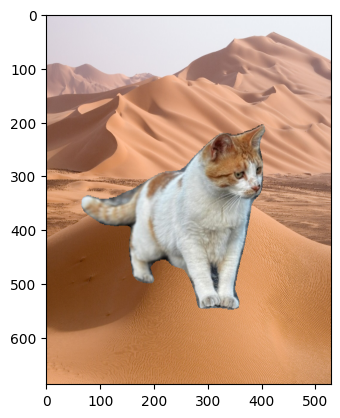

In [12]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

# 1. 학습목표 인물모드 사진의 문제점을 개선할 수 있는 솔루션을 적절히 제시하였다.
세그멘테이션 에서 잘못 찾아내는 영역에 대해
딥러닝 기반의 시맨틱 세그멘테이션(Semantic Segmentation) 과정에서 옷, 의자, 장신구 등 인물이 아닌 요소가 인물(Person) 마스크에 잘못 포함되는 문제는 프로젝트나 실제 서비스 개발 시 매우 흔히 발생하는 한계입니다.

단순히 "더 좋은 모델을 쓴다"를 넘어, DeepLab 모델이 만들어낸 마스크(Mask) 영역의 품질을 메커니즘적으로 보완할 수 있는 대표적인 소프트웨어 및 하드웨어 해결 방안을 정리해 드립니다.

1. 소프트웨어적 접근: 마스크 후처리 및 구조 개선
DeepLab이 출력한 2D 마스크 이미지 자체의 정밀도를 알고리즘으로 다듬거나, 객체의 구조를 파악하는 방식입니다.

① CRF (Conditional Random Field) 알고리즘 적용
DeepLab 모델의 최종 출력은 픽셀 단위의 확률 지도입니다. 경계선이 흐릿하거나 인접한 옷이 인물로 오인되었을 때, CRF를 후처리(Post-processing)로 적용하면 큰 효과를 볼 수 있습니다.

메커니즘: CRF는 픽셀 간의 거리(소속 위치)와 색상 유사도(Color Similarity)를 동시에 고려합니다. 인물 마스크 내부 영역과 배경(또는 잘못 포함된 옷) 영역의 색상 차이가 명확하다면, CRF가 경계면의 픽셀 밀도를 재조정하여 옷처럼 색상이 크게 다른 구획을 인물 마스크에서 날카롭게 잘라냅니다.

② Edge Detection 및 Morphological 연산 융합
이미지의 외곽선 정보를 추출하여 마스크를 보정하는 방법입니다.

메커니즘: 원본 이미지에 Canny나 Sobel 같은 에지 검출(Edge Detection) 알고리즘을 적용해 실제 물체의 경계선을 파악합니다. DeepLab 마스크가 옷까지 침범했더라도, 에지 맵(Edge Map)과 비교했을 때 급격한 경계선 변화가 있는 지점을 기준으로 마스크를 깎아내는(Erosion/Opening) 모폴로지 연산을 수행하여 오검출을 줄입니다.

③ Instance Segmentation 모델로의 전환 (Mask R-CNN 등)
Semantic Segmentation은 '픽셀'이 사람인지 아닌지만 구분하지만, Instance Segmentation은 개별 객체를 먼저 탐지합니다.

메커니즘: 인물의 대략적인 바운딩 박스(Bounding Box)를 먼저 잡고 그 안에서 마스크를 생성하기 때문에, 박스 밖에 걸쳐 있거나 인물의 실루엣과 동떨어진 배경 오브젝트(벽에 걸린 옷 등)가 사람의 일부로 통째로 묶이는 오류를 원천적으로 방지할 수 있습니다.

2. 하드웨어 융합 접근: 3D Depth 정보 활용
2D 이미지의 픽셀 정보만으로는 완벽한 구분이 불가능할 때, 거리(Depth) 데이터를 결합하여 공간적으로 분리하는 방식입니다. 최근 스마트폰 인물 모드에서 가장 핵심적으로 사용되는 메커니즘입니다.

① Depth Map(깊이 지도)과 마스크의 AND 연산
스마트폰의 듀얼/트리플 카메라(Stereo Vision)나 ToF(Time-of-Flight) 센서를 통해 촬영된 사진은 픽셀마다 카메라와의 거리를 담은 Depth Map을 가집니다.

메커니즘: 1. DeepLab을 통해 얻은 2D 인물 마스크(Mask A)를 준비합니다.
2. 주인공(인물)이 위치한 초점 거리 $D_{target}$을 기준 값으로 잡고, 이 거리 범위를 벗어나는 영역을 필터링한 거리 마스크(Mask B)를 생성합니다.
3. 두 마스크를 비트 연산(AND) 합니다. 얼굴과 몸은 카메라와 가깝고 벽에 걸린 옷은 멀리 있다면, 거리 마스크(Mask B)에서 옷 부분이 0(배경)으로 처리되므로 최종 합성 마스크에서 옷이 완벽히 제거됩니다.

[2D 이미지] ──> DeepLab 모델 ──────> 인물 마스크 (A) 
                                         │
                                         ▼ (AND 연산) ──> 최종 정밀 마스크 ──> 아웃포커싱 적용
                                         ▲
[ToF 센서]  ──> 깊이 예측 필터 ──> 거리 마스크 (B)
② uDepth (IR/적외선 센서 융합)
구글 픽셀 등에서 제안된 방식으로, 일반 RGB 이미지 외에 적외선 패턴을 쏘아 공간을 인식하는 기술입니다.

메커니즘: 빛의 조건이 불리하거나 옷과 피부의 색상이 유사해 2D 신경망이 헷갈리는 상황에서도, IR 패턴의 왜곡 정도를 통해 실시간으로 정밀한 3D 메쉬(Mesh)를 그리므로 2D 세그멘테이션의 한계를 하드웨어 레벨에서 보완합니다.

💡 추천하는 결론 및 제안 방향
프로젝트 보고서를 작성하실 때는 **"DeepLab이 출력한 인물 마스크 레이어와 스마트폰 센서 정보로 추출한 Depth Map 레이어를 픽셀 단위로 곱하는(AND) 구조의 파이프라인"**을 제안하시는 것을 추천합니다. 2D의 한계를 3D 공간 정보가 어떻게 메커니즘적으로 상쇄하는지 흐름도(Flow Chart)와 함께 설명하면 아주 훌륭한 솔루션이 됩니다.

# 학습목표 2 인물사진에서 발생한 문제점 지적한 사진 제출
뒤에 배경이 이상하게 짤려서 사막과 어울러지지 않는 문제 발생

원본 고양이 이미지 크기: (923, 680, 3)
배경(사막) 이미지 크기: (1280, 1920, 3)


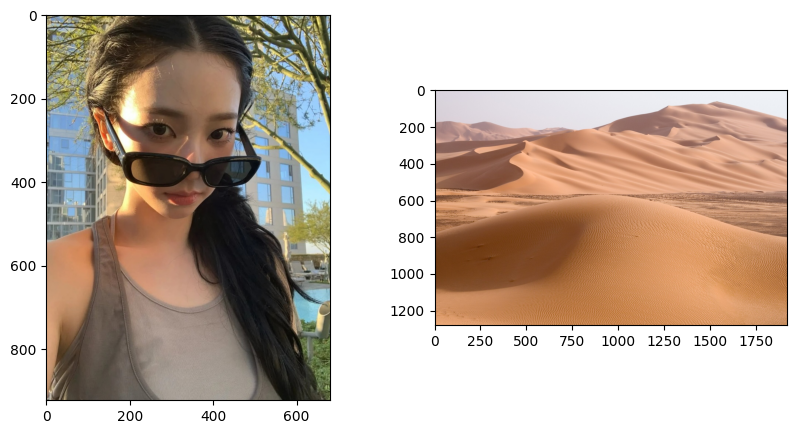

추론 마스크 크기 (Before Resize): (520, 520)
추론 마스크 크기 (After Resize): (923, 680)
추론 마스크 크기 (After Resize): (923, 680)
예측된 클래스 ID: [ 0 15]


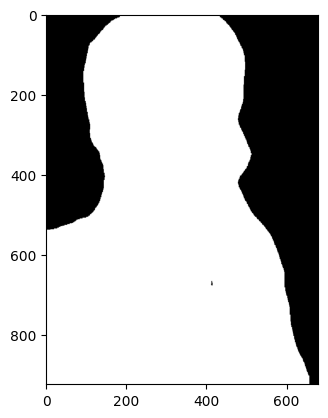

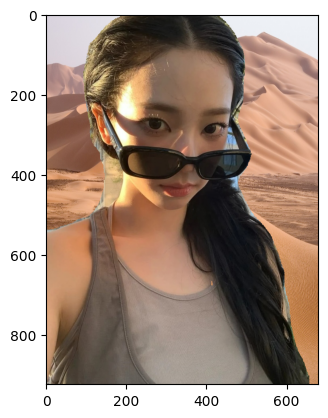

In [14]:
cat_img_path = "carina.jpg"  # 인물 이미지를 준비해주세요
sand_img_path = "sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")


# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")


unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")


target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

# 학습 목표 3 아웃포커싱 효과가 적용된 인물모드 사진과 동물 사진, 배경전환 크로마키사진을 각각 1장 이상 성공적으로 제작하였다.


원본 이미지 크기: (923, 680, 3)


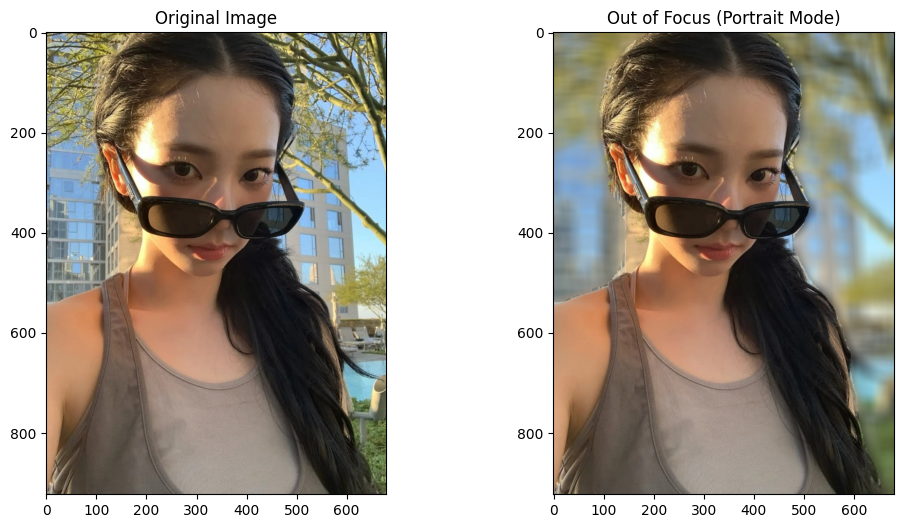

In [16]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

# 1. 원본 이미지 준비 (카리나 인물 사진)
cat_img_path = "carina.jpg" 
cat_img = cv2.imread(cat_img_path)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

print(f"원본 이미지 크기: {cat_img.shape}")

# 2. 원본 이미지를 흐리게(Blur) 만들어 배경 이미지 생성
# (ksize 값이 커질수록 배경이 더 고르게, 많이 흐려집니다)
bg_blur_img = cv2.blur(cat_img, ksize=(30, 30)) 

# 3. 딥러닝 모델 준비 및 추론
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 4. 마스크를 원본 크기로 복원
output_predictions_resized = cv2.resize(
    output_predictions, 
    (cat_img.shape[1], cat_img.shape[0]), 
    interpolation=cv2.INTER_NEAREST
)

# 5. 추출할 타겟 클래스(인물/고양이) 마스크 생성
unique_classes = np.unique(output_predictions_resized)
# 보통 인물이 하나만 있으면 배경(0) 외에 인물 클래스 ID가 세그멘테이션 맵에 남습니다.
# 만약 클래스가 여러 개 잡힌다면 명확한 클래스 ID(예: 사람은 15)를 직접 지정해 주는 것이 안전합니다.
target_class_id = unique_classes[-1] 

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

# 6. 아웃포커싱 합성 (정확한 3채널 비교를 위해 컬러 채널 맞춤)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# 마스크가 255(흰색, 주인공 영역)인 곳은 원본(cat_img)을, 
# 아닌 곳(배경 영역)은 흐리게 만든 이미지(bg_blur_img)를 선택합니다.
result_img = np.where(img_mask_color == 255, cat_img, bg_blur_img)

# 7. 최종 결과 출력
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.title("Out of Focus (Portrait Mode)")
plt.imshow(result_img)
plt.show()

원본 이미지 크기: (687, 529, 3)


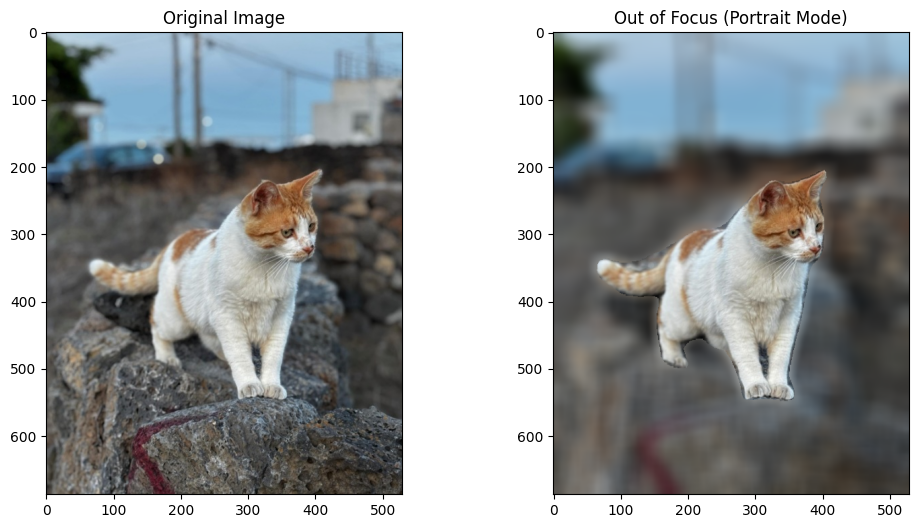

In [17]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

# 1. 원본 이미지 준비 (카리나 인물 사진)
cat_img_path = "cat.jpg" 
cat_img = cv2.imread(cat_img_path)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)

print(f"원본 이미지 크기: {cat_img.shape}")

# 2. 원본 이미지를 흐리게(Blur) 만들어 배경 이미지 생성
# (ksize 값이 커질수록 배경이 더 고르게, 많이 흐려집니다)
bg_blur_img = cv2.blur(cat_img, ksize=(30, 30)) 

# 3. 딥러닝 모델 준비 및 추론
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

# 4. 마스크를 원본 크기로 복원
output_predictions_resized = cv2.resize(
    output_predictions, 
    (cat_img.shape[1], cat_img.shape[0]), 
    interpolation=cv2.INTER_NEAREST
)

# 5. 추출할 타겟 클래스(인물/고양이) 마스크 생성
unique_classes = np.unique(output_predictions_resized)
# 보통 인물이 하나만 있으면 배경(0) 외에 인물 클래스 ID가 세그멘테이션 맵에 남습니다.
# 만약 클래스가 여러 개 잡힌다면 명확한 클래스 ID(예: 사람은 15)를 직접 지정해 주는 것이 안전합니다.
target_class_id = unique_classes[-1] 

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

# 6. 아웃포커싱 합성 (정확한 3채널 비교를 위해 컬러 채널 맞춤)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# 마스크가 255(흰색, 주인공 영역)인 곳은 원본(cat_img)을, 
# 아닌 곳(배경 영역)은 흐리게 만든 이미지(bg_blur_img)를 선택합니다.
result_img = np.where(img_mask_color == 255, cat_img, bg_blur_img)

# 7. 최종 결과 출력
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.title("Out of Focus (Portrait Mode)")
plt.imshow(result_img)
plt.show()

1. 